In [ ]:
# Conectarse al drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# IR a la carpeta UTEC
%cd /content/drive/MyDrive/Curso\ Mineria\ de\ Datos\ 2024/

/content/drive/MyDrive/Curso Mineria de Datos 2024


In [ ]:
import pandas as pd

# Cargar la base de datos
data = pd.read_csv('Home_loan.csv')

# Tomar una muestra aleatoria de 10,000 datos
sample_data = data.sample(n=10000, random_state=24)

# Ver las primeras filas
sample_data.head()


,sk_id_curr,name_contract_type,code_gender,flag_own_car,flag_own_realty,cnt_children,amt_income_total,amt_credit,amt_annuity,amt_goods_price,...,amt_req_credit_bureau_qrt,amt_req_credit_bureau_year,target,loan_rate,loan_income_ratio,annuity_income_ratio,es1_is_missing,es3_is_missing,application_is_incomplete,kfold
129648,454025,Cash loans,F,N,Y,0,175500.0,1035832.5,30285.0,904500.0,...,0.0,2.0,0,34.202823,5.902179,0.172564,False,False,True,4
160041,255187,Cash loans,F,Y,N,0,292500.0,454500.0,31630.5,454500.0,...,0.0,2.0,0,14.369043,1.553846,0.108138,False,False,False,4
79456,441206,Cash loans,F,Y,N,0,171000.0,276277.5,19359.0,238500.0,...,0.0,1.0,0,14.271269,1.615658,0.113211,True,False,False,0
50792,108298,Cash loans,M,Y,N,0,180000.0,1223010.0,45454.5,1125000.0,...,3.0,6.0,0,26.906247,6.794500,0.252525,True,True,True,4
147821,130222,Cash loans,F,N,N,0,211500.0,810000.0,29223.0,810000.0,...,0.0,2.0,0,27.717893,3.829787,0.138170,False,False,True,1


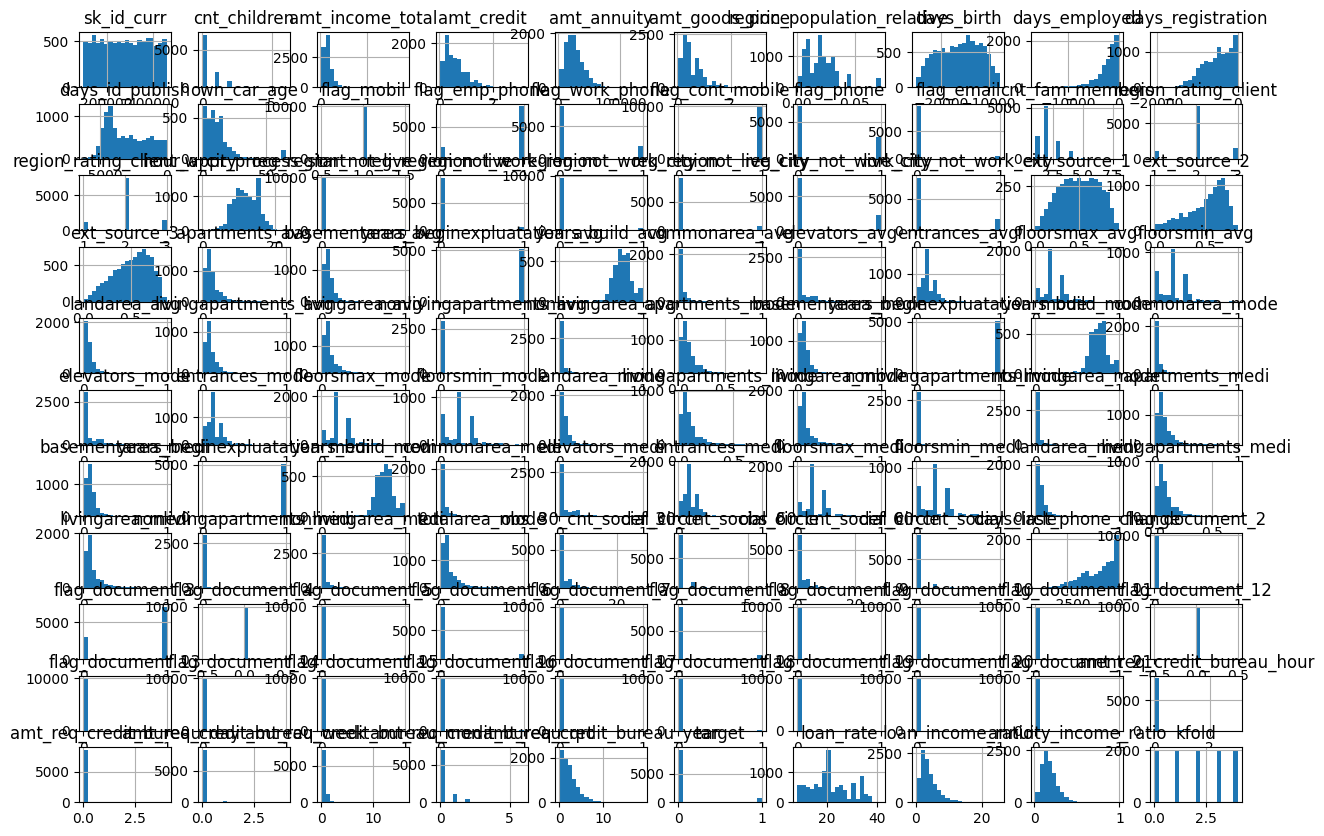

In [ ]:
import matplotlib.pyplot as plt

# Seleccionar solo las variables numéricas
numeric_vars = sample_data.select_dtypes(include='number')

# Graficar histogramas
numeric_vars.hist(bins=20, figsize=(15, 10))
plt.show()


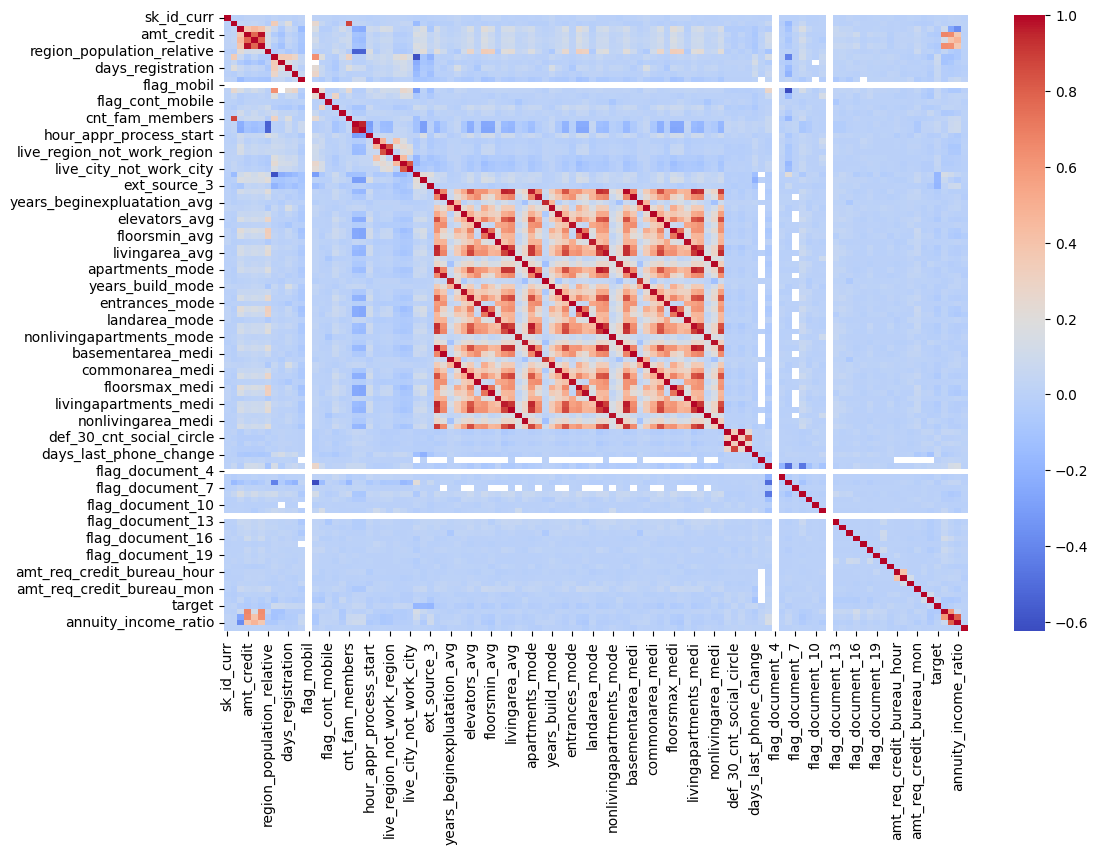

In [ ]:
import seaborn as sns
import numpy as np

# Calcular la matriz de correlación
correlation_matrix = numeric_vars.corr()

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.show()


In [ ]:
# Definir un umbral: si una variable numérica tiene menos de este número de valores únicos,
# la consideramos categórica (esto puede ajustarse según los datos)
threshold = 10

# Encontrar columnas numéricas que tienen pocos valores únicos
potential_categorical = [col for col in sample_data.select_dtypes(include='number').columns
                         if sample_data[col].nunique() < threshold]

In [ ]:
potential_categorical

['cnt_children',
 'flag_mobil',
 'flag_emp_phone',
 'flag_work_phone',
 'flag_cont_mobile',
 'flag_phone',
 'flag_email',
 'cnt_fam_members',
 'region_rating_client',
 'region_rating_client_w_city',
 'reg_region_not_live_region',
 'reg_region_not_work_region',
 'live_region_not_work_region',
 'reg_city_not_live_city',
 'reg_city_not_work_city',
 'live_city_not_work_city',
 'def_30_cnt_social_circle',
 'def_60_cnt_social_circle',
 'flag_document_2',
 'flag_document_3',
 'flag_document_4',
 'flag_document_5',
 'flag_document_6',
 'flag_document_7',
 'flag_document_8',
 'flag_document_9',
 'flag_document_10',
 'flag_document_11',
 'flag_document_12',
 'flag_document_13',
 'flag_document_14',
 'flag_document_15',
 'flag_document_16',
 'flag_document_17',
 'flag_document_18',
 'flag_document_19',
 'flag_document_20',
 'flag_document_21',
 'amt_req_credit_bureau_hour',
 'amt_req_credit_bureau_day',
 'amt_req_credit_bureau_week',
 'amt_req_credit_bureau_qrt',
 'target',
 'kfold']

In [ ]:
# Convertir estas columnas a tipo 'category'
for col in potential_categorical:
    sample_data[col] = sample_data[col].astype('category')

# Verificar el cambio
sample_data.dtypes

,0
sk_id_curr,int64
name_contract_type,object
code_gender,object
flag_own_car,object
flag_own_realty,object
...,...
annuity_income_ratio,float64
es1_is_missing,bool
es3_is_missing,bool
application_is_incomplete,bool


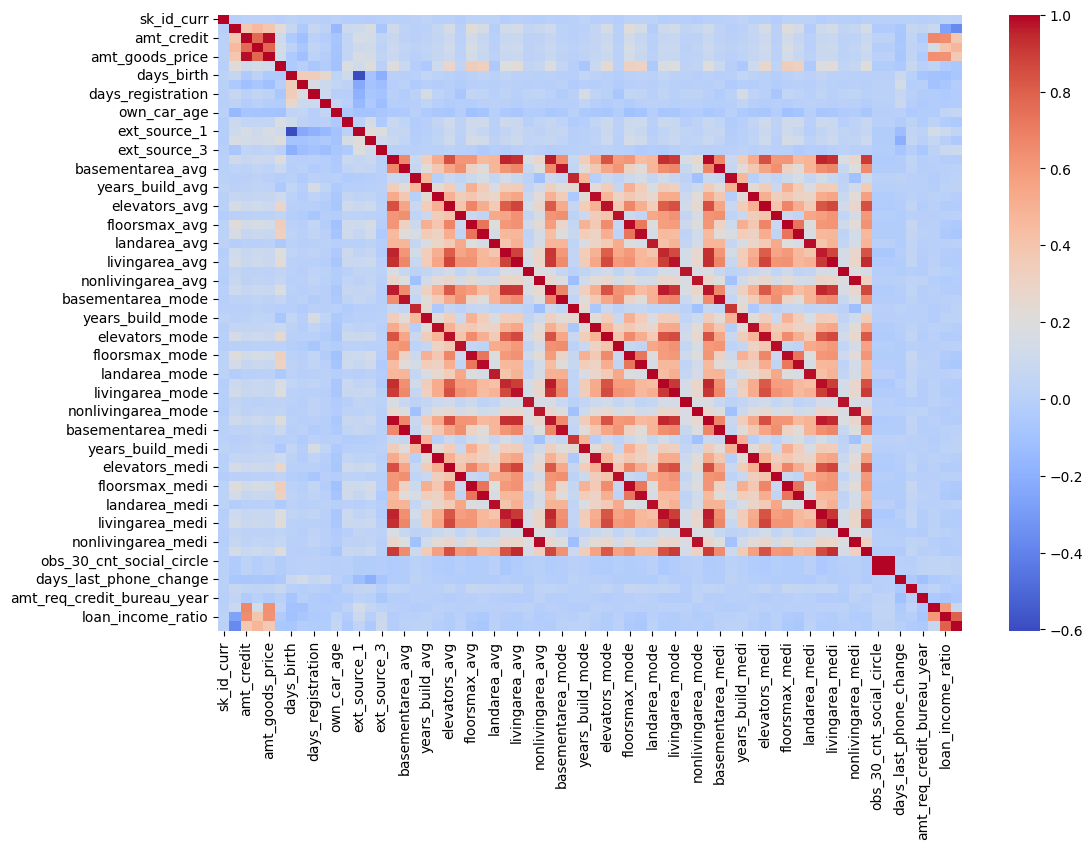

In [ ]:
# Calcular la matriz de correlación
correlation_matrix = sample_data.select_dtypes(include='number').corr()

# Graficar el mapa de calor
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt='.2f')
plt.show()

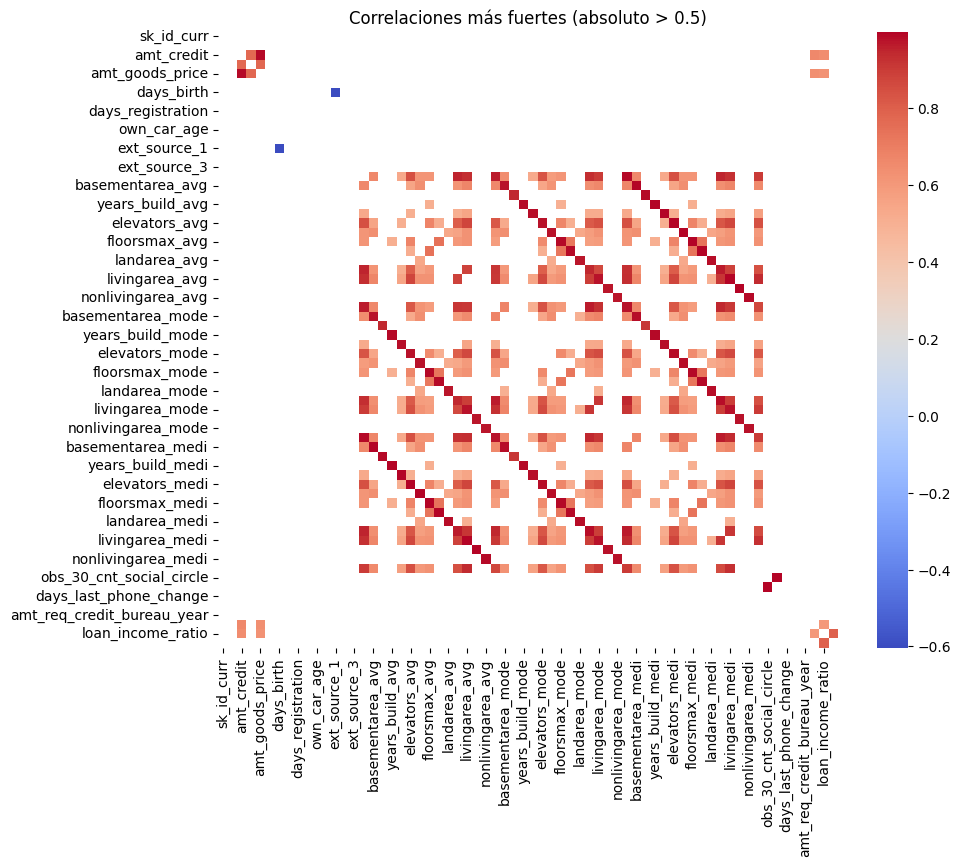

In [ ]:
# Recalcular la matriz de correlación
correlation_matrix = sample_data.select_dtypes(include='number').corr()

# Filtrar solo las correlaciones con valores absolutos > 0.5
strong_correlations = correlation_matrix[(correlation_matrix.abs() > 0.5) & (correlation_matrix != 1.0)]

# Mostrar el nuevo mapa de calor con las correlaciones fuertes
plt.figure(figsize=(10, 8))
sns.heatmap(strong_correlations, annot=False, cmap='coolwarm', fmt='.2f', mask=strong_correlations.isnull())
plt.title('Correlaciones más fuertes (absoluto > 0.5)')
plt.show()

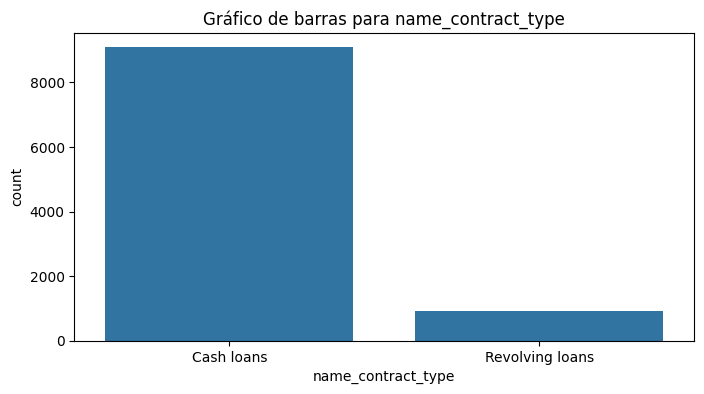

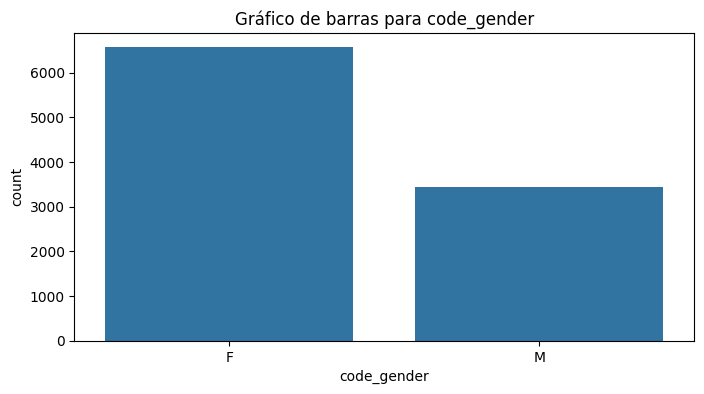

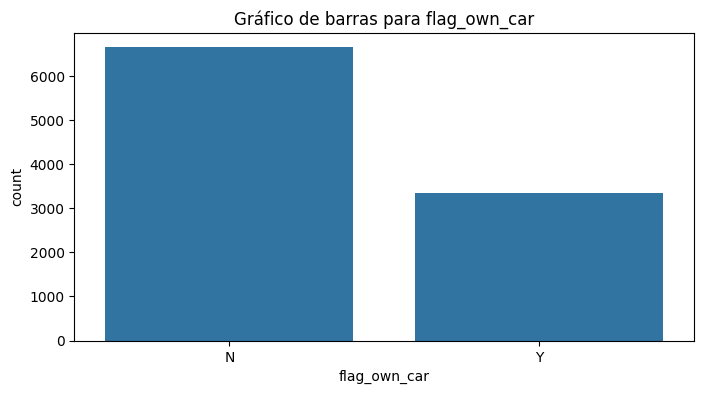

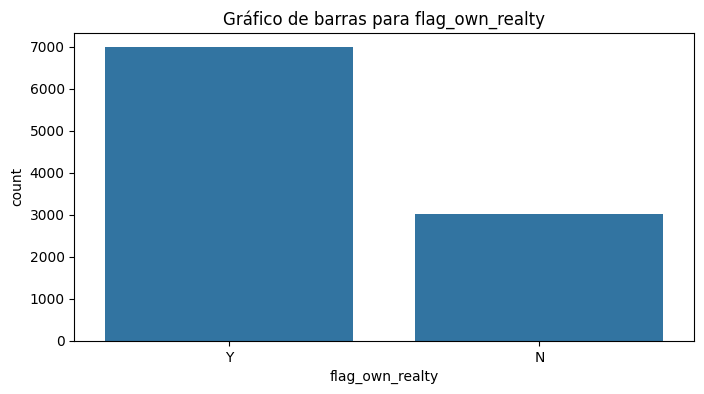

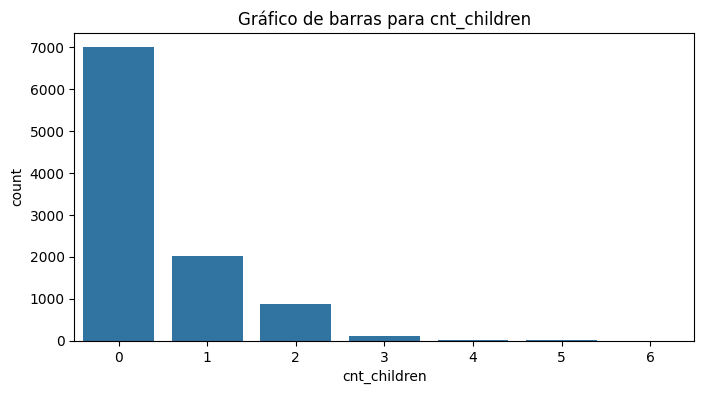

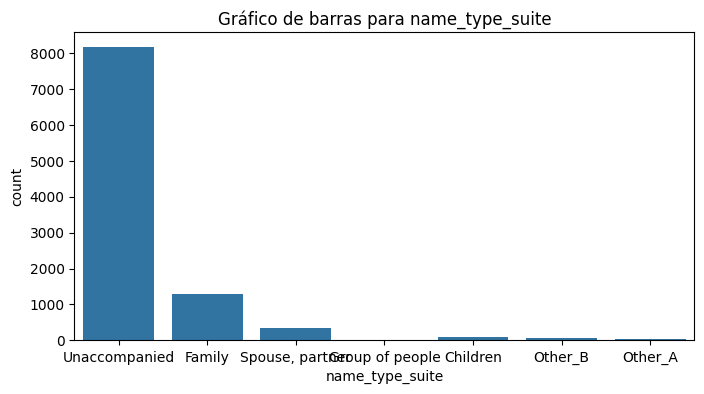

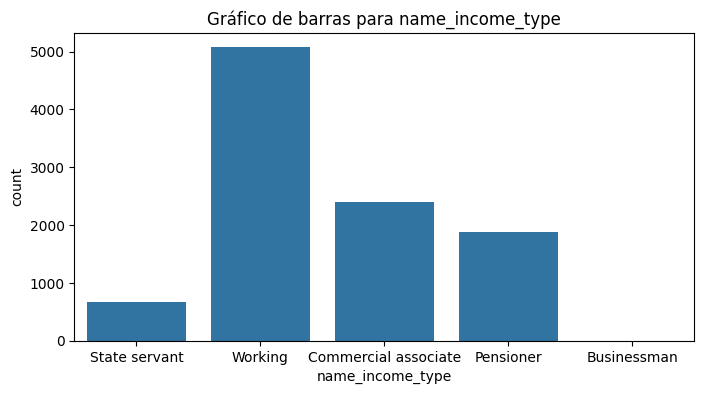

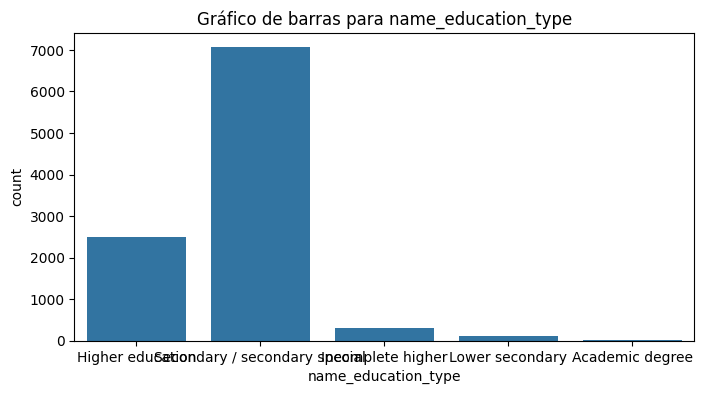

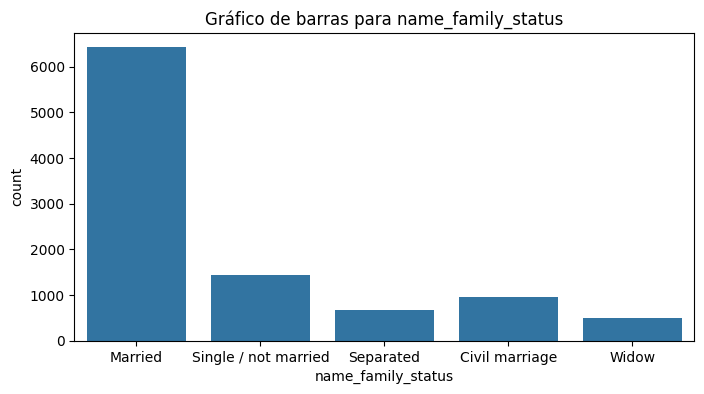

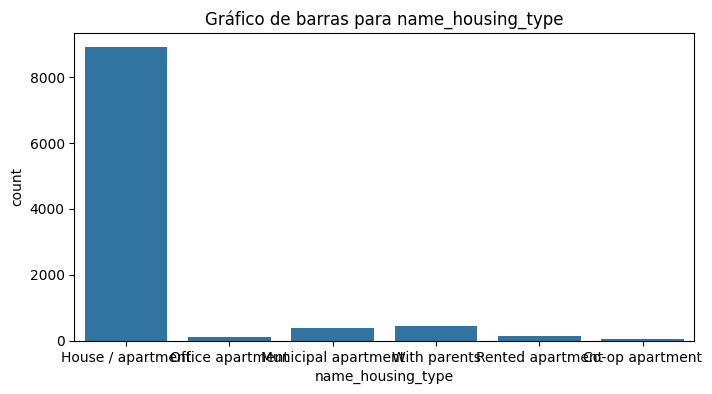

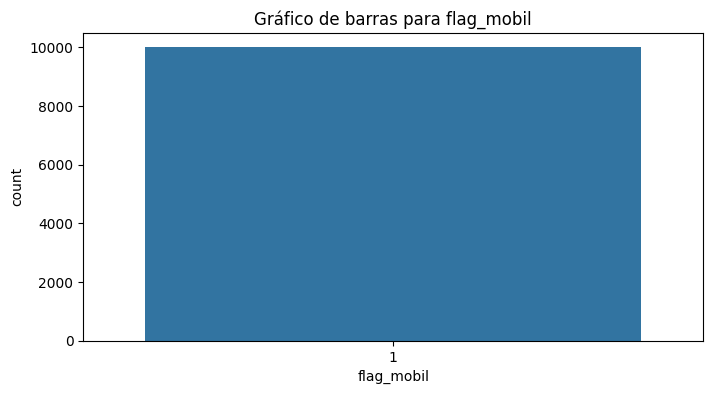

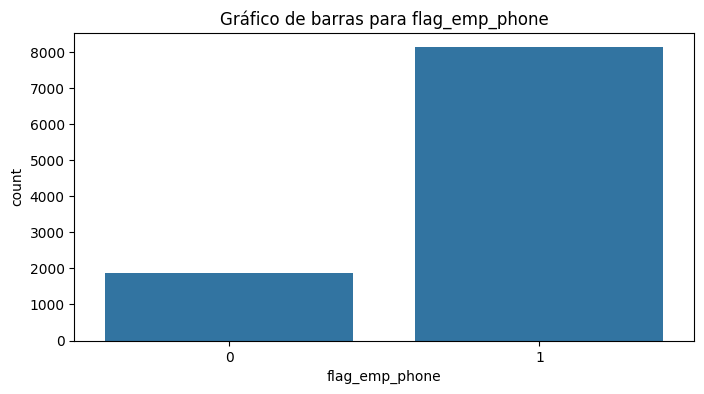

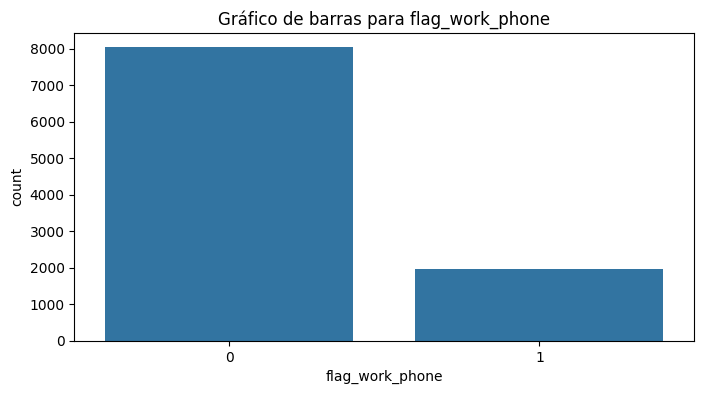

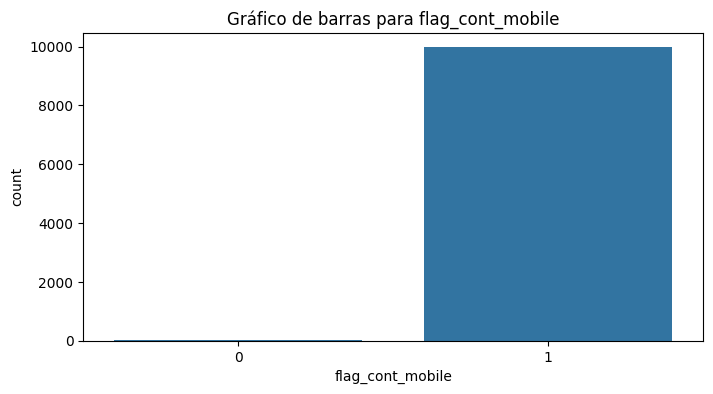

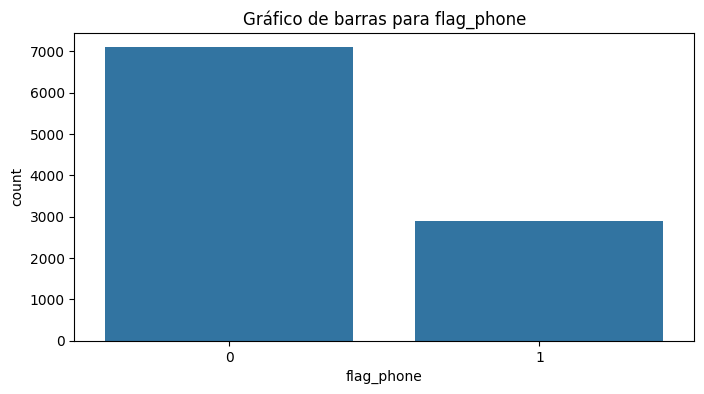

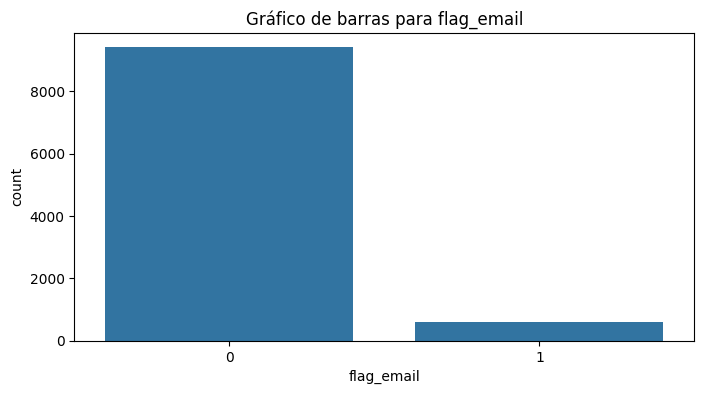

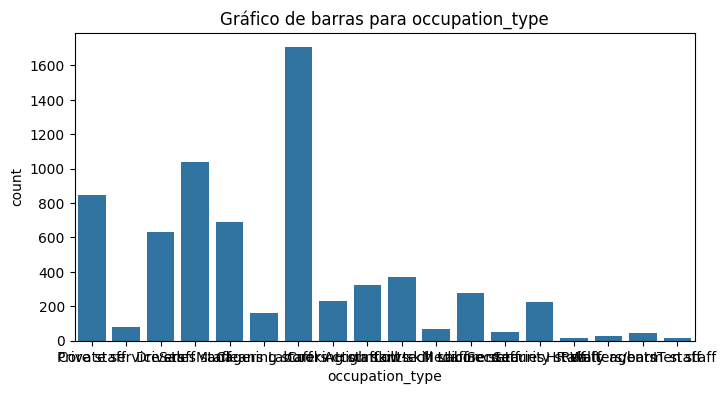

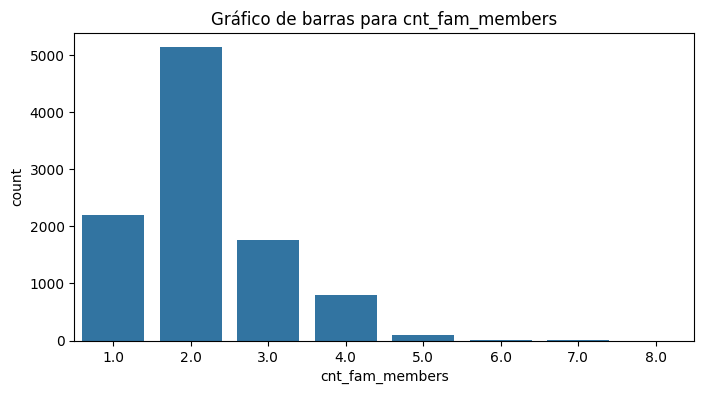

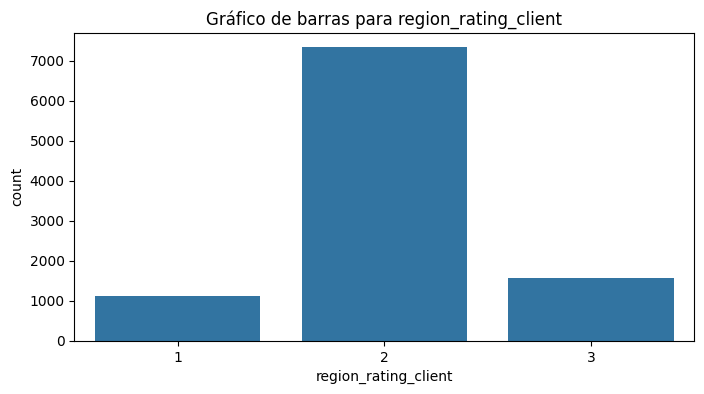

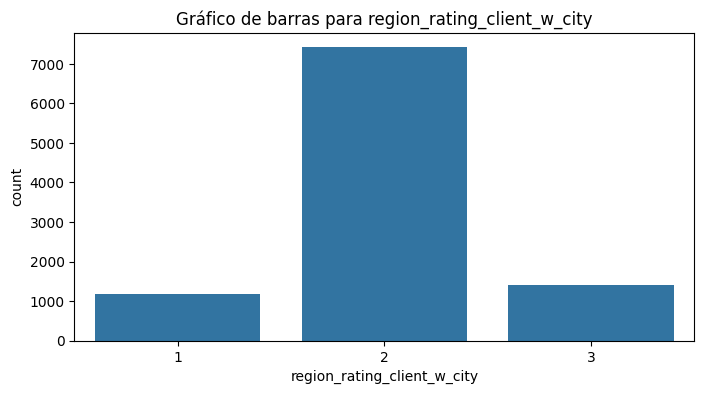

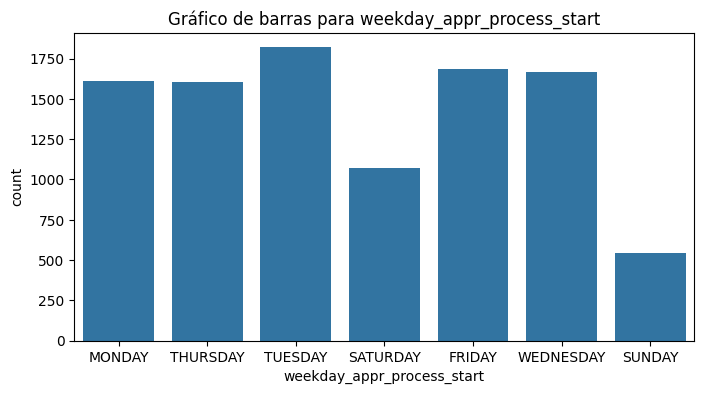

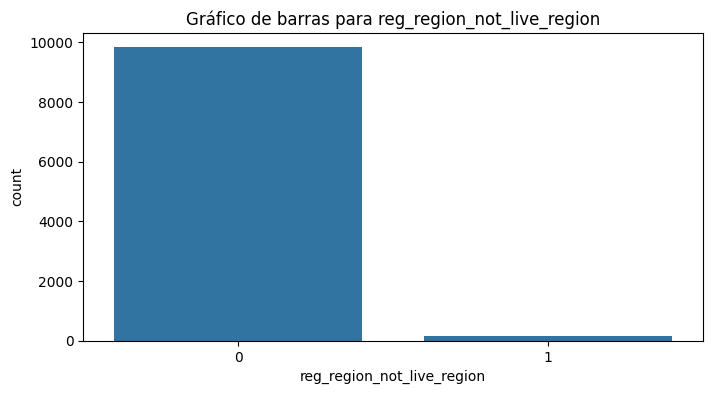

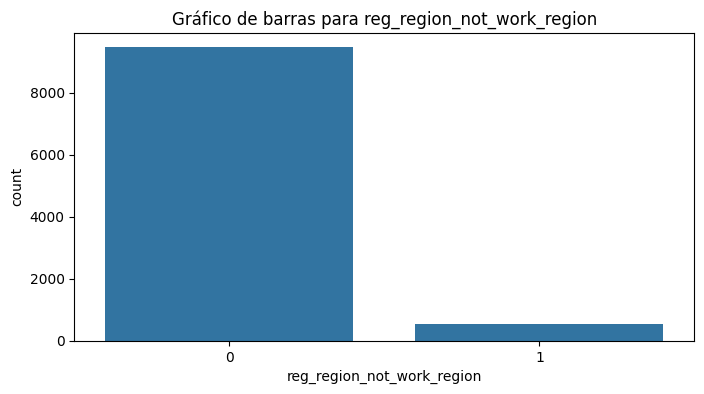

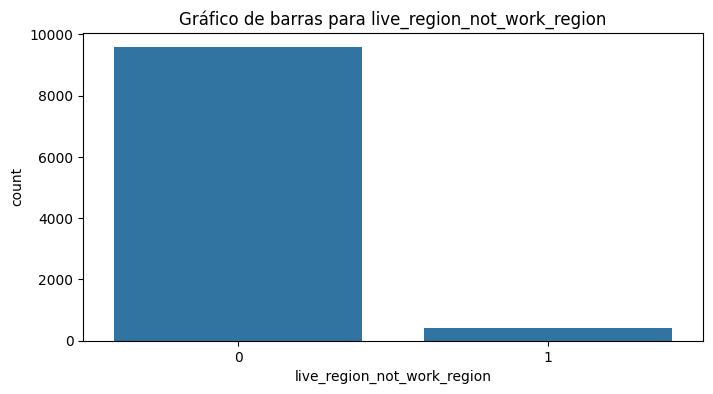

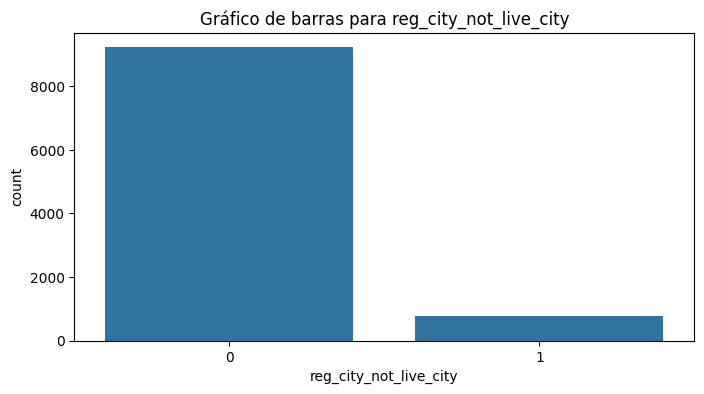

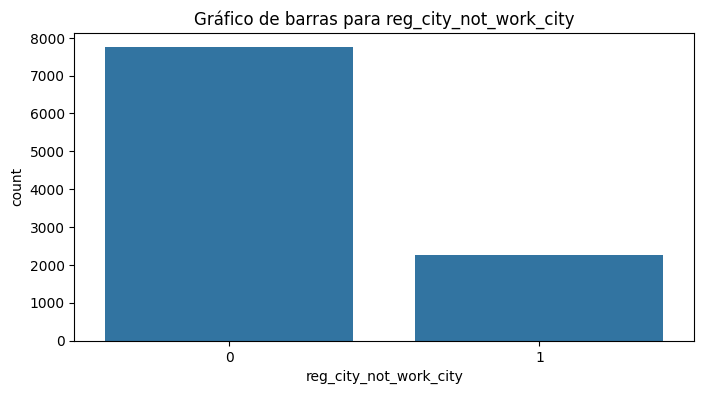

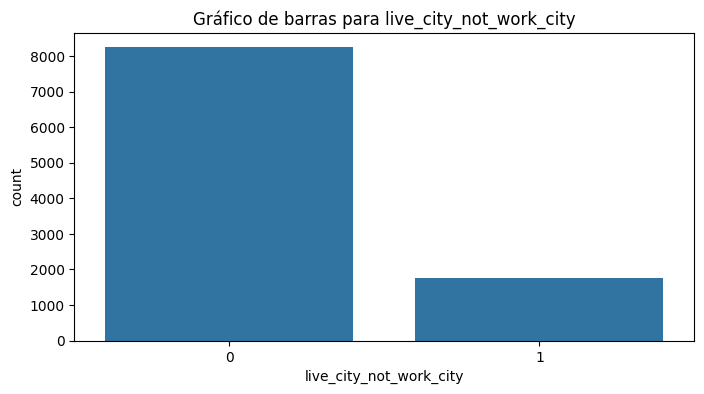

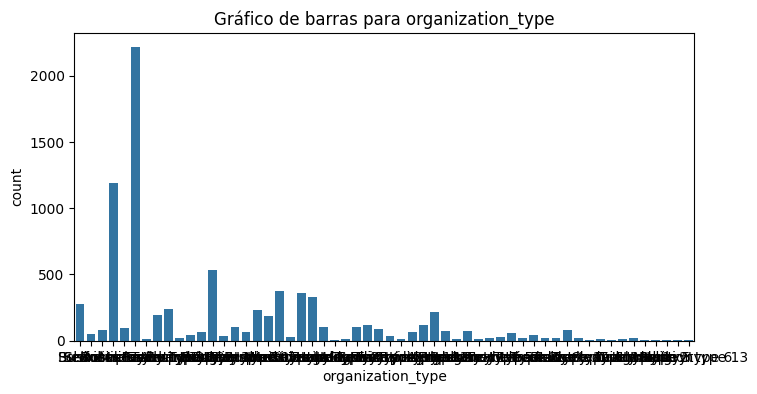

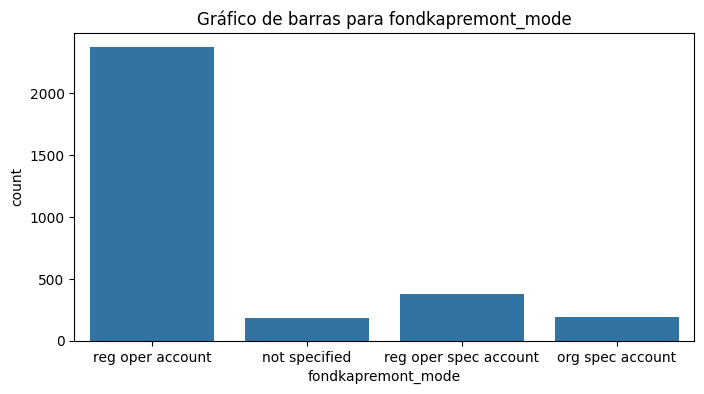

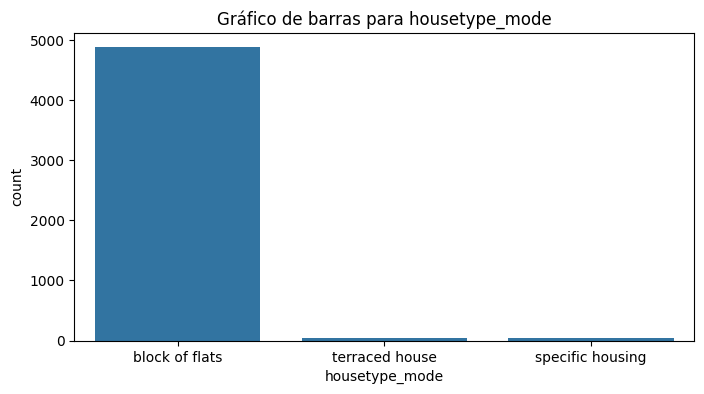

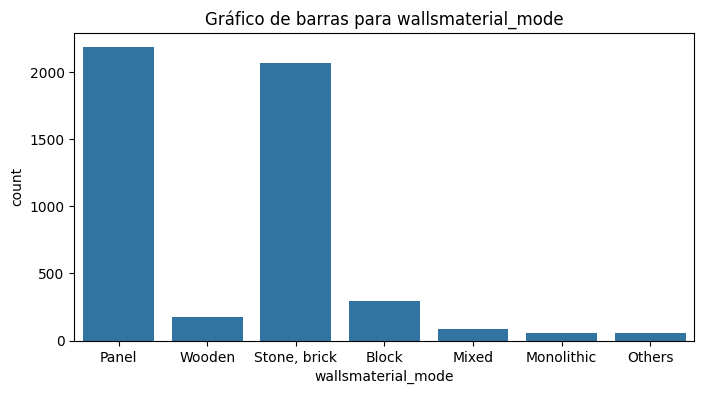

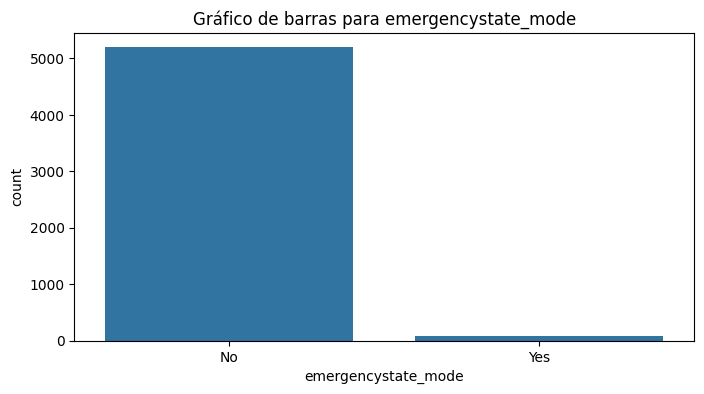

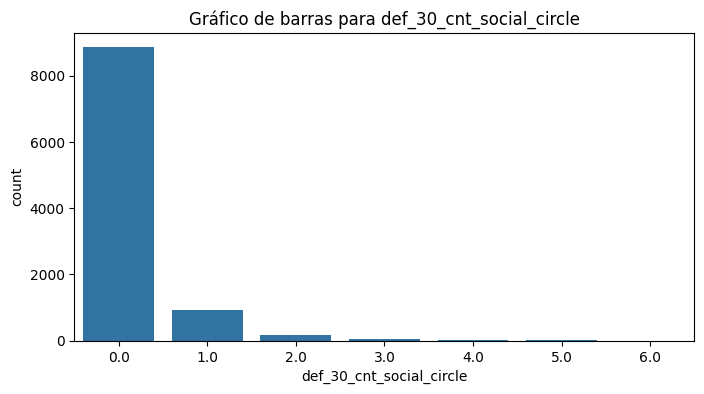

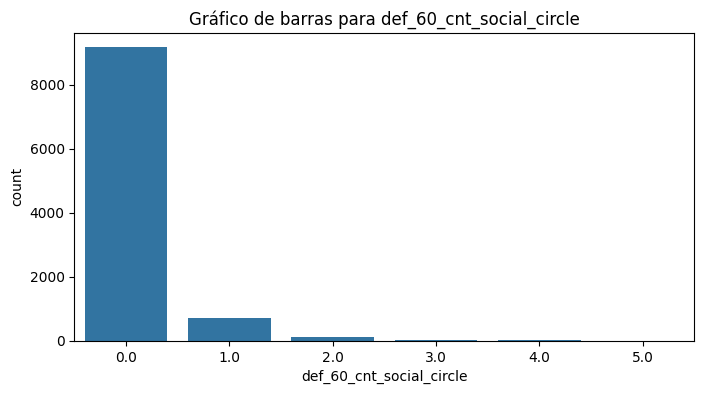

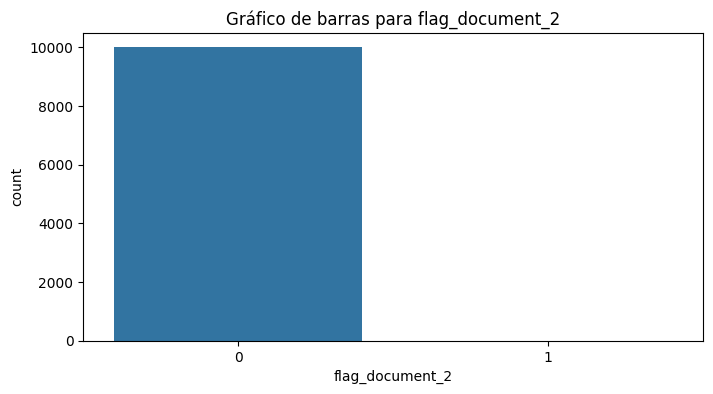

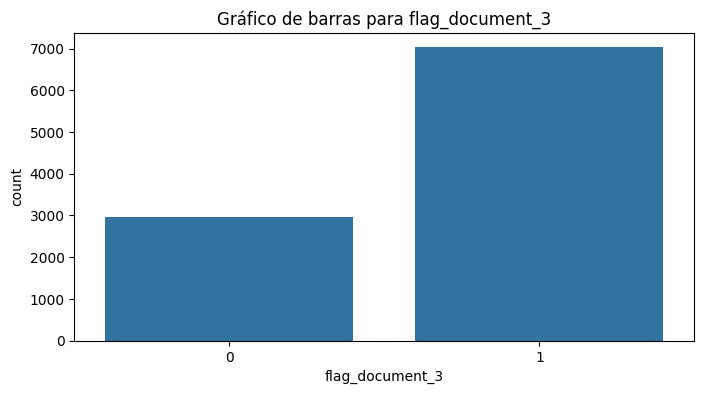

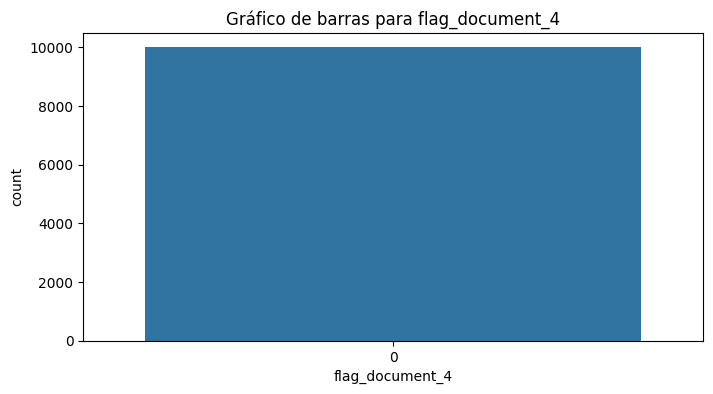

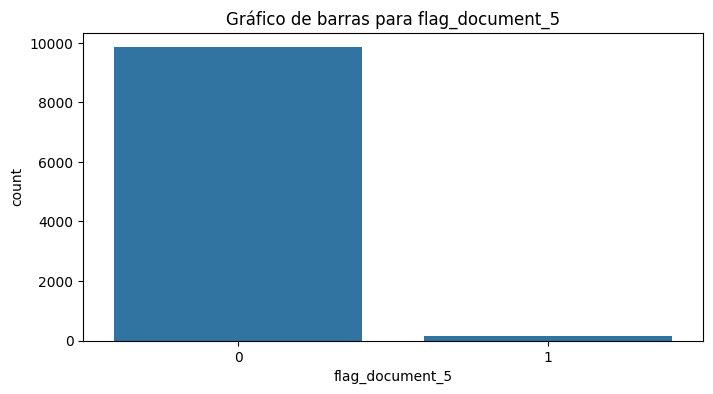

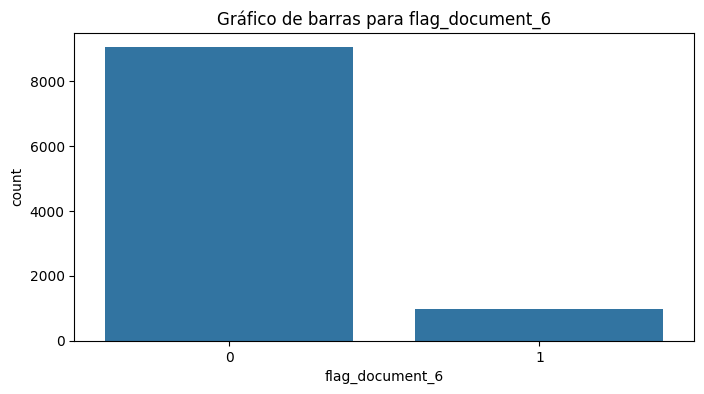

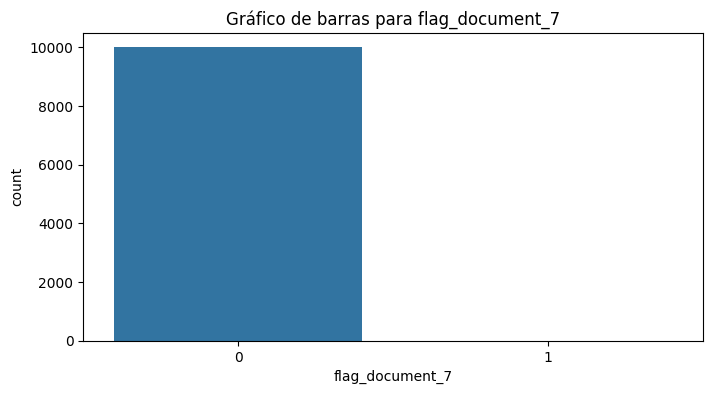

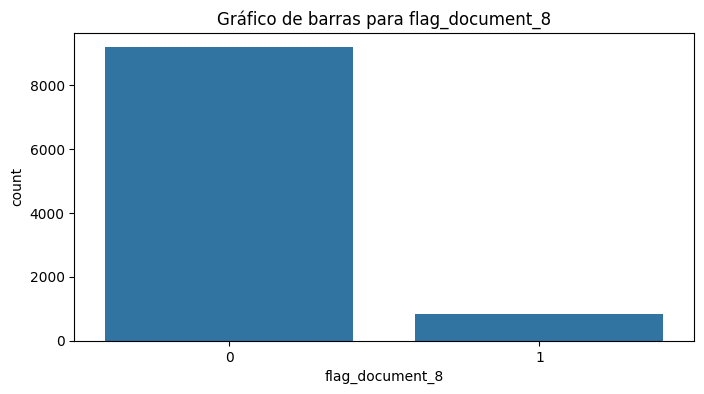

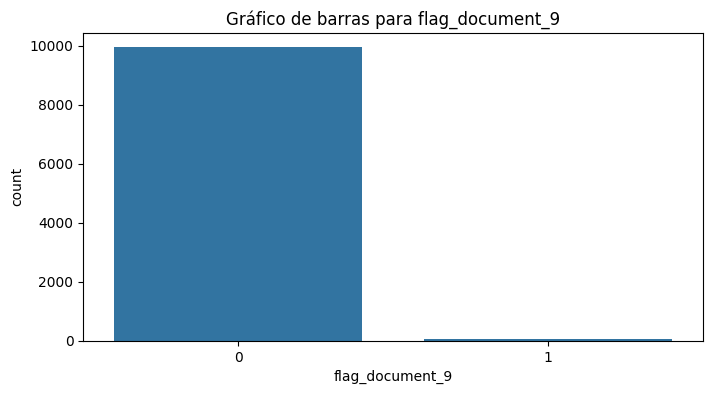

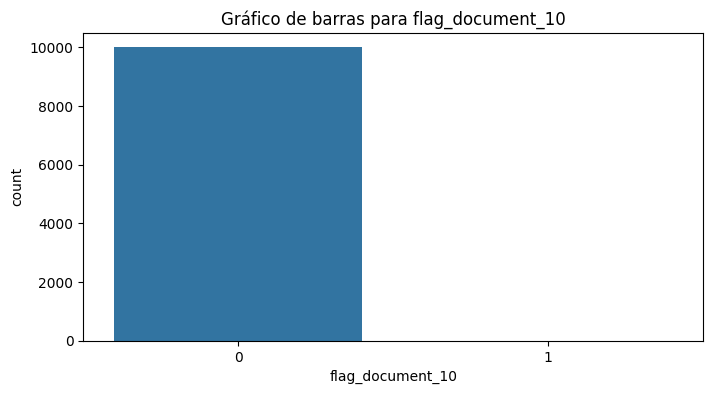

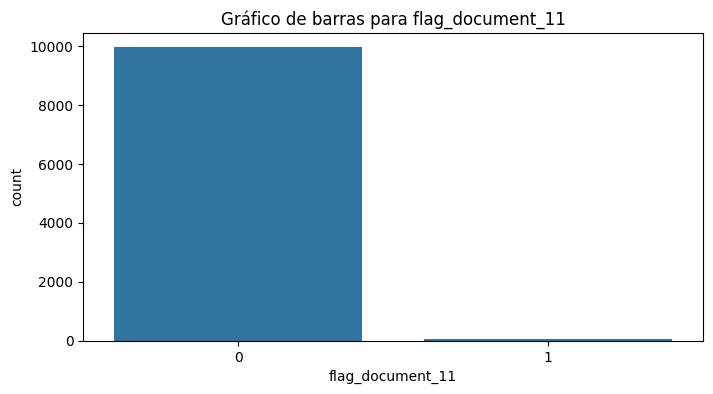

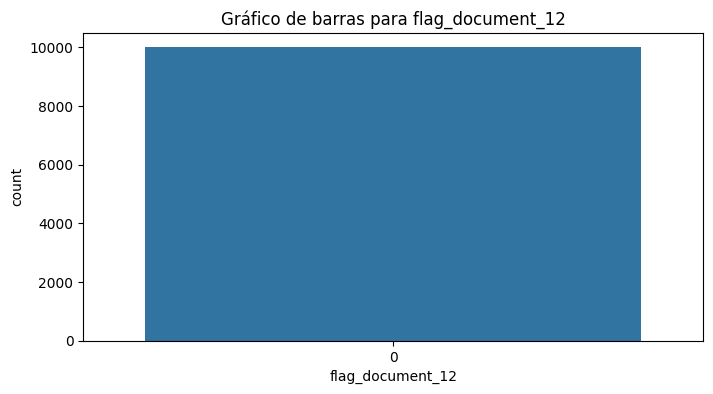

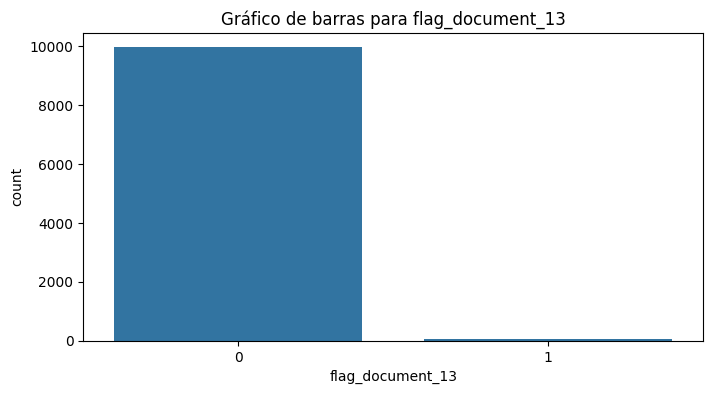

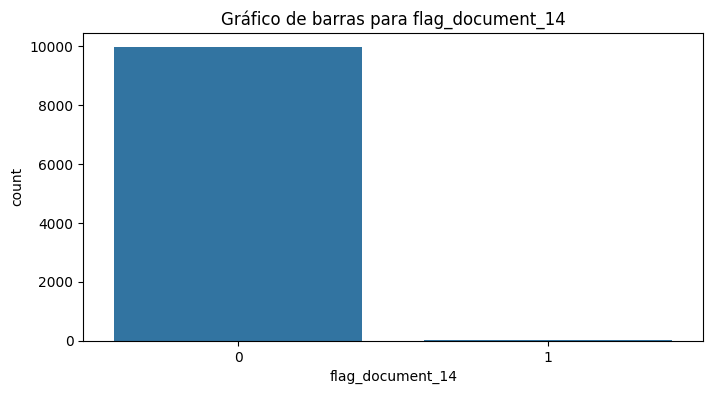

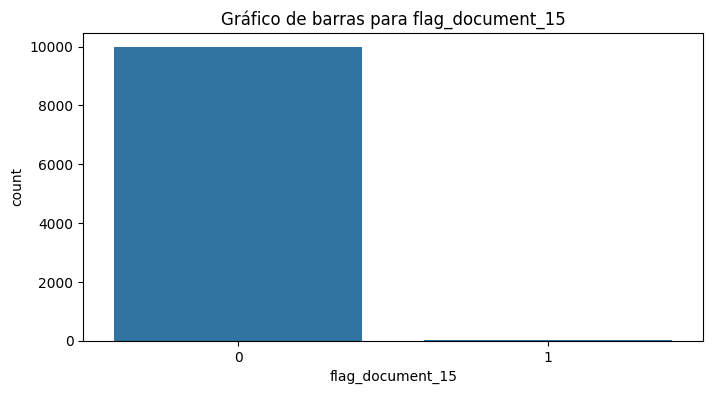

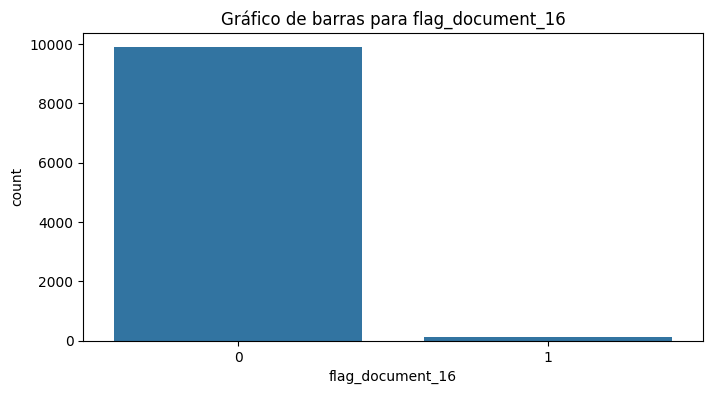

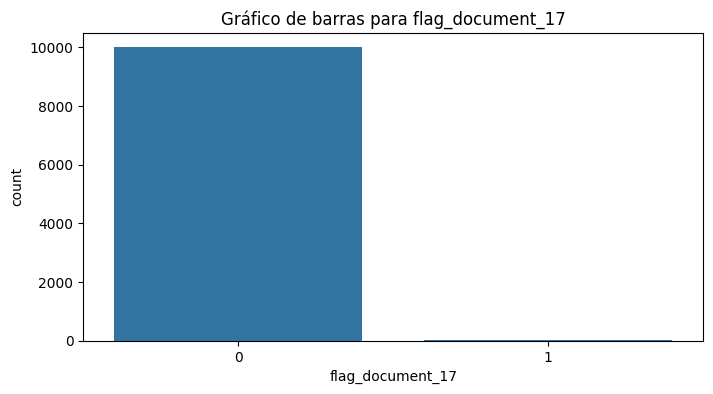

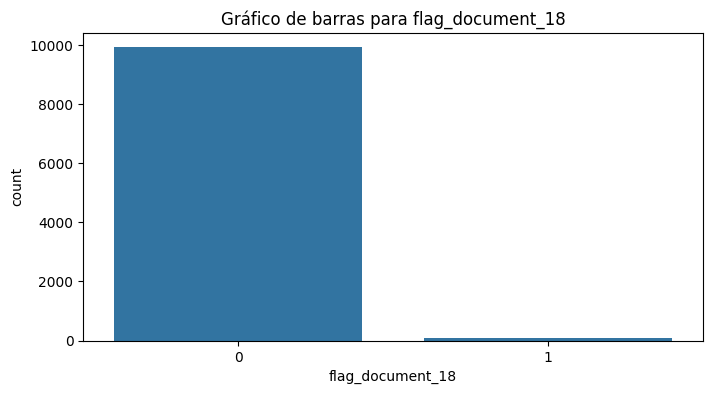

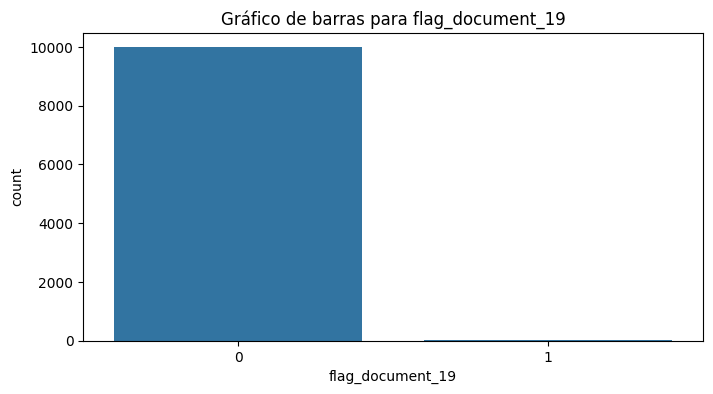

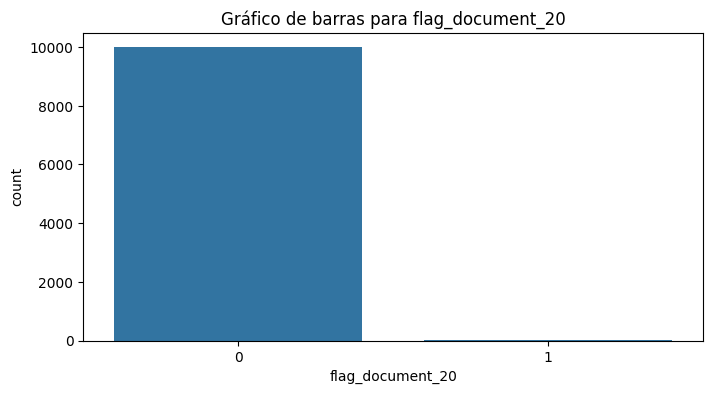

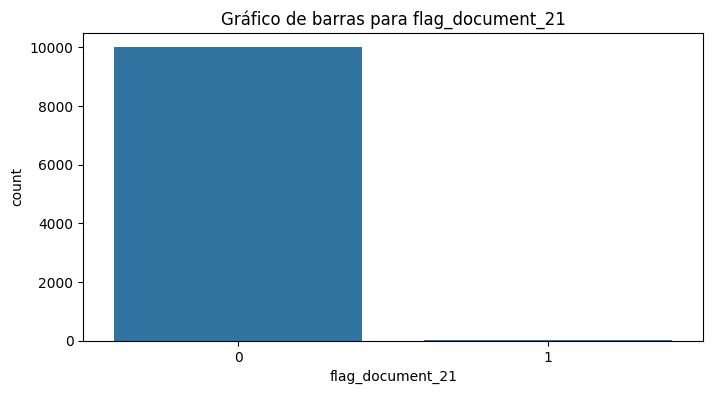

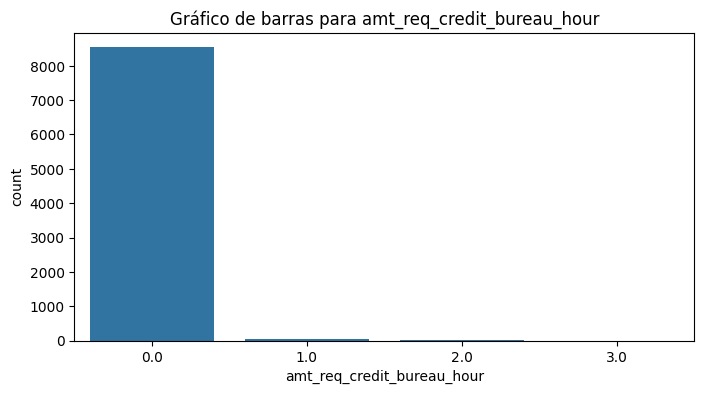

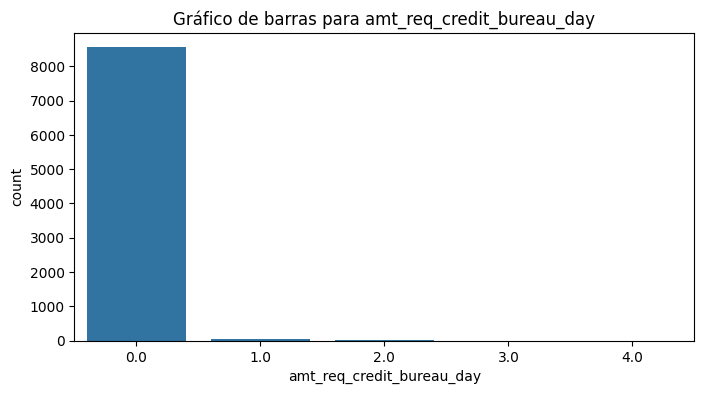

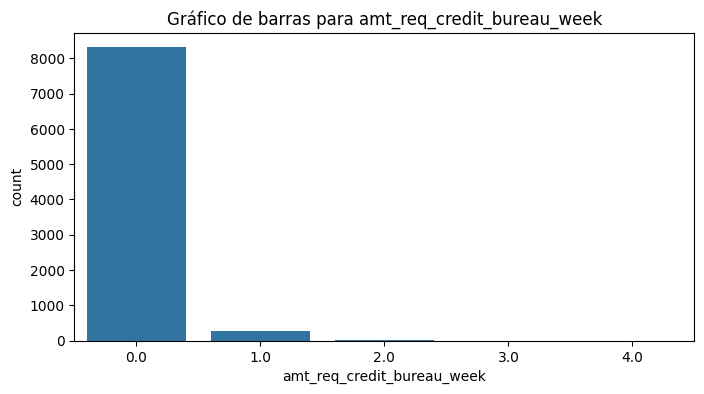

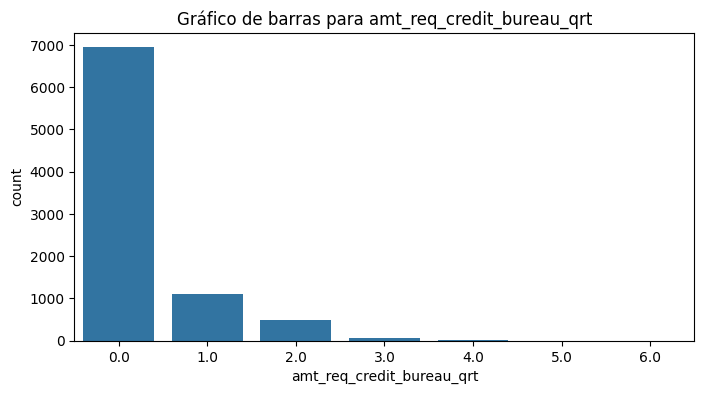

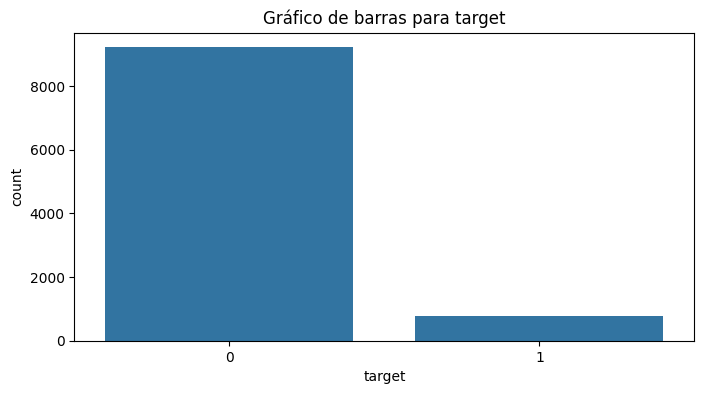

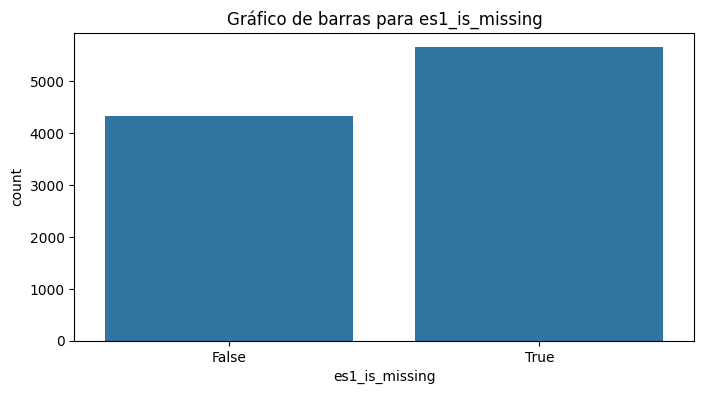

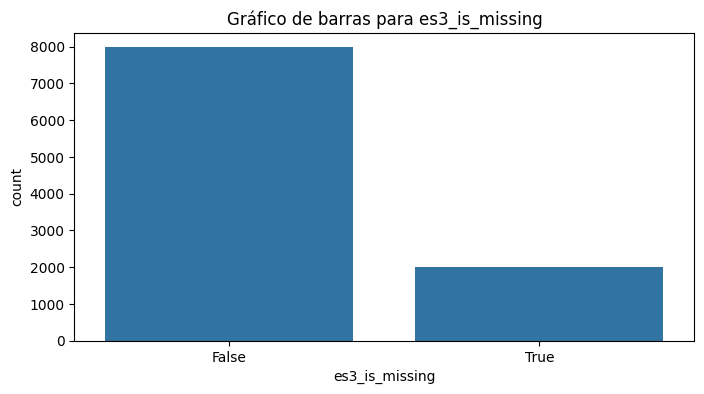

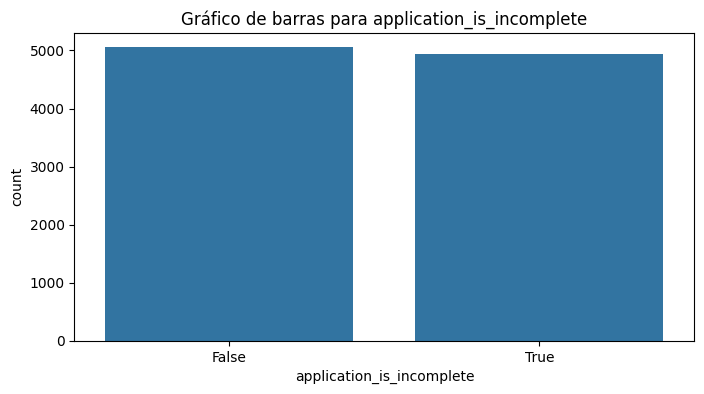

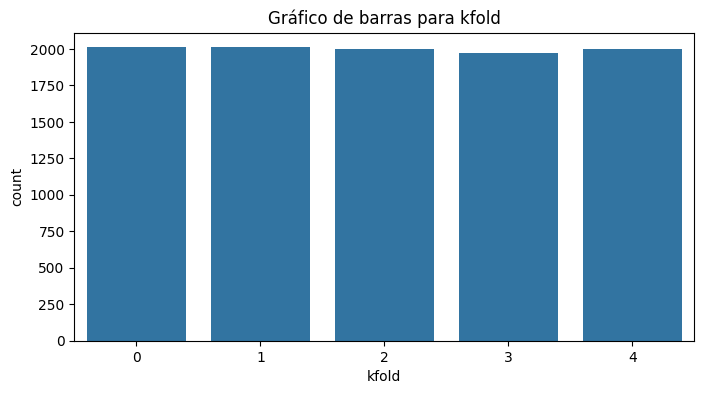

In [ ]:
categorical_vars = sample_data.select_dtypes(exclude='number')

# Graficar todas las variables categóricas
for column in categorical_vars.columns:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=column, data=sample_data)
    plt.title(f'Gráfico de barras para {column}')
    plt.show()


In [ ]:
# Resumen descriptivo
summary = sample_data.describe()

summary

,sk_id_curr,amt_income_total,amt_credit,amt_annuity,amt_goods_price,region_population_relative,days_birth,days_employed,days_registration,days_id_publish,...,nonlivingarea_medi,totalarea_mode,obs_30_cnt_social_circle,obs_60_cnt_social_circle,days_last_phone_change,amt_req_credit_bureau_mon,amt_req_credit_bureau_year,loan_rate,loan_income_ratio,annuity_income_ratio
count,10000.000000,1.000000e+04,1.000000e+04,10000.000000,1.000000e+04,10000.000000,10000.000000,8127.000000,10000.000000,10000.000000,...,4478.000000,5192.000000,10000.000000,10000.000000,10000.000000,8595.000000,8595.000000,10000.000000,10000.000000,10000.000000
mean,277901.190000,1.690493e+05,6.012919e+05,27178.763400,5.402958e+05,0.021092,-16114.745600,-2363.332103,-5027.686100,-2994.549400,...,0.027810,0.104301,1.439100,1.422400,-959.580000,0.270622,1.898429,21.579065,3.973594,0.181392
std,103283.726303,9.778183e+04,4.107231e+05,14514.920585,3.766805e+05,0.014057,4374.088578,2318.118752,3560.130996,1522.584545,...,0.071176,0.108895,2.330415,2.314458,830.421613,0.920795,1.876521,7.852832,2.754493,0.096143
min,100029.000000,2.700000e+04,4.500000e+04,2781.000000,4.500000e+04,0.000533,-25149.000000,-16538.000000,-20569.000000,-6226.000000,...,0.000000,0.000000,0.000000,0.000000,-4066.000000,0.000000,0.000000,8.036739,0.156541,0.011483
25%,187050.750000,1.125000e+05,2.700000e+05,16423.875000,2.385000e+05,0.010032,-19758.250000,-3131.000000,-7595.000000,-4303.250000,...,0.000000,0.042000,0.000000,0.000000,-1566.000000,0.000000,0.000000,15.603032,2.000000,0.113451
50%,278231.000000,1.440000e+05,5.094000e+05,24930.000000,4.500000e+05,0.018850,-15848.000000,-1645.000000,-4521.500000,-3264.000000,...,0.002900,0.069200,0.000000,0.000000,-753.000000,0.000000,1.000000,20.000000,3.237700,0.162143
75%,368241.500000,2.025000e+05,8.086500e+05,34911.000000,6.795000e+05,0.028663,-12503.000000,-751.500000,-1947.750000,-1685.000000,...,0.025875,0.130100,2.000000,2.000000,-271.000000,0.000000,3.000000,27.020603,5.166667,0.229234
max,456251.000000,1.800000e+06,3.150000e+06,135463.500000,3.150000e+06,0.072508,-7681.000000,-3.000000,0.000000,-1.000000,...,1.000000,1.000000,29.000000,29.000000,0.000000,16.000000,19.000000,41.534989,25.454545,0.989934


In [ ]:
# Valores nulos
missing_values = sample_data.isnull().sum()

# Datos duplicados
duplicates = sample_data.duplicated().sum()

missing_values, duplicates


(sk_id_curr                   0
 name_contract_type           0
 code_gender                  0
 flag_own_car                 0
 flag_own_realty              0
                             ..
 annuity_income_ratio         0
 es1_is_missing               0
 es3_is_missing               0
 application_is_incomplete    0
 kfold                        0
 Length: 129, dtype: int64,
 0)

In [ ]:
sample_data.shape

(10000, 129)

In [ ]:
# Valores nulos
missing_values = sample_data.isnull().sum()

# Filtrar solo las columnas con valores nulos distintos de cero
missing_values = missing_values[missing_values > 0]

# Datos duplicados
duplicates = sample_data.duplicated().sum()

# Mostrar resultados
print("Valores nulos (distintos de cero):")
print(missing_values)

if duplicates > 0:
    print(f"\nNúmero de filas duplicadas: {duplicates}")
else:
    print("\nNo hay filas duplicadas.")


Valores nulos (distintos de cero):
days_employed                   1873
own_car_age                     6649
occupation_type                 3204
organization_type               1873
ext_source_1                    5661
ext_source_3                    2015
apartments_avg                  5064
basementarea_avg                5881
years_beginexpluatation_avg     4860
years_build_avg                 6734
commonarea_avg                  7057
elevators_avg                   5341
entrances_avg                   5011
floorsmax_avg                   4949
floorsmin_avg                   6869
landarea_avg                    5969
livingapartments_avg            6908
livingarea_avg                  5018
nonlivingapartments_avg         7008
nonlivingarea_avg               5522
apartments_mode                 5064
basementarea_mode               5881
years_beginexpluatation_mode    4860
years_build_mode                6734
commonarea_mode                 7057
elevators_mode                  5341
ent

In [ ]:
missing_values.shape

(59,)

In [ ]:
# Calcular el porcentaje de valores nulos por columna
null_percentage = sample_data.isnull().mean() * 100

# Filtrar las columnas con un porcentaje de nulos mayor o igual al 30%
columns_to_drop = null_percentage[null_percentage >= 30].index

# Eliminar las columnas
sample_data_cleaned = sample_data.drop(columns=columns_to_drop)

# Mostrar las columnas eliminadas
print(f"Columnas eliminadas debido a más del 30% de valores nulos: {list(columns_to_drop)}")

# Mostrar la forma del nuevo DataFrame
print(f"Dimensiones del DataFrame después de eliminar columnas: {sample_data_cleaned.shape}")


Columnas eliminadas debido a más del 30% de valores nulos: ['own_car_age', 'occupation_type', 'ext_source_1', 'apartments_avg', 'basementarea_avg', 'years_beginexpluatation_avg', 'years_build_avg', 'commonarea_avg', 'elevators_avg', 'entrances_avg', 'floorsmax_avg', 'floorsmin_avg', 'landarea_avg', 'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg', 'nonlivingarea_avg', 'apartments_mode', 'basementarea_mode', 'years_beginexpluatation_mode', 'years_build_mode', 'commonarea_mode', 'elevators_mode', 'entrances_mode', 'floorsmax_mode', 'floorsmin_mode', 'landarea_mode', 'livingapartments_mode', 'livingarea_mode', 'nonlivingapartments_mode', 'nonlivingarea_mode', 'apartments_medi', 'basementarea_medi', 'years_beginexpluatation_medi', 'years_build_medi', 'commonarea_medi', 'elevators_medi', 'entrances_medi', 'floorsmax_medi', 'floorsmin_medi', 'landarea_medi', 'livingapartments_medi', 'livingarea_medi', 'nonlivingapartments_medi', 'nonlivingarea_medi', 'fondkapremont_mode', 

In [ ]:
sample_data.columns

Index(['sk_id_curr', 'name_contract_type', 'code_gender', 'flag_own_car',
       'flag_own_realty', 'cnt_children', 'amt_income_total', 'amt_credit',
       'amt_annuity', 'amt_goods_price',
       ...
       'amt_req_credit_bureau_qrt', 'amt_req_credit_bureau_year', 'target',
       'loan_rate', 'loan_income_ratio', 'annuity_income_ratio',
       'es1_is_missing', 'es3_is_missing', 'application_is_incomplete',
       'kfold'],
      dtype='object', length=129)

In [ ]:
from sklearn.model_selection import train_test_split

# Definir la variable objetivo (y) y el resto de las variables (X)
X = sample_data_cleaned.drop('loan_rate', axis=1)
y = sample_data_cleaned['loan_rate']

# Dividir los datos (90% entrenamiento, 10% testeo)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=24)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((9000, 78), (1000, 78), (9000,), (1000,))

In [ ]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np
import pandas as pd

# Definir las variables numéricas y categóricas
numeric_features = X_train.select_dtypes(include='number').columns

categorical_features = X_train.select_dtypes(exclude='number').columns

# Crear un pipeline para las variables numéricas (imputación + escalado)
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', MinMaxScaler())
])

# Crear un pipeline para las variables categóricas (imputación + codificación One-Hot sin sparse matrix)
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first', sparse_output=False))  # Sparse output set to False
])

# Combinar ambos pipelines utilizando ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

# Aplicar el preprocesador a los datos de entrenamiento y prueba
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

# Verificar la forma de los datos transformados
print(f"Shape of X_train_transformed (after preprocessing): {X_train_transformed.shape}")
print(f"Shape of X_test_transformed (after preprocessing): {X_test_transformed.shape}")

# Obtener los nombres de todas las características preprocesadas
all_feature_names = list(numeric_features) + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_features))

# Crear un DataFrame con las características transformadas
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=all_feature_names)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=all_feature_names)

# Verificar el contenido del DataFrame
print(X_train_transformed_df.head())
print(X_test_transformed_df.head())


Shape of X_train_transformed (after preprocessing): (9000, 190)
Shape of X_test_transformed (after preprocessing): (1000, 190)
   sk_id_curr  amt_income_total  amt_credit  amt_annuity  amt_goods_price  \
0    0.782394          0.027919    0.050725     0.056288         0.050725   
1    0.510328          0.073604    0.277986     0.350521         0.256522   
2    0.361606          0.071066    0.111594     0.171449         0.111594   
3    0.567208          0.050761    0.040580     0.118749         0.040580   
4    0.326485          0.073604    0.245942     0.160895         0.202899   

   region_population_relative  days_birth  days_employed  days_registration  \
0                    0.419896    0.314336       0.724161           0.584715   
1                    0.251490    0.360502       0.889568           0.546210   
2                    0.245585    0.048227       0.856566           0.717099   
3                    0.194331    0.724039       0.899788           0.807769   
4              